In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler,OneHotEncoder, FunctionTransformer
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn import set_config
from sklearn.base import BaseEstimator, TransformerMixin, OneToOneFeatureMixin
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_score
from sklearn.ensemble import RandomForestRegressor, BaggingRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.inspection import permutation_importance
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report, 
    roc_auc_score, 
    confusion_matrix,
    precision_recall_curve,
    roc_curve
)
from imblearn.over_sampling import SMOTE
import warnings
warnings.filterwarnings('ignore')



In [2]:
data = pd.read_csv('../data/space_weather_aligned.csv', parse_dates=['time'], index_col='time')
df = pd.read_csv('../data/space_weather_aligned.csv', parse_dates=['time'], index_col='time')
print(data.head()) 
print(data.info())

                           BX        BY        BZ       V_SW       N_p  \
time                                                                     
2015-09-01 00:00:00  3.624878 -2.462927 -0.862439  361.65897  4.485641   
2015-09-01 01:00:00       NaN       NaN       NaN        NaN       NaN   
2015-09-01 02:00:00  3.047500 -3.918846 -0.222115  365.07758  5.437551   
2015-09-01 03:00:00  2.460667 -3.617667 -2.332167  366.65454  5.548364   
2015-09-01 04:00:00  2.928667 -3.238833 -1.130667  367.12964  5.745740   

                        P_dyn     SYM_H  Dst          AE        Kp  \
time                                                                 
2015-09-01 00:00:00  1.174103 -3.566667 -6.0  151.366667  1.666667   
2015-09-01 01:00:00       NaN  0.216667 -3.0   88.983333  1.666667   
2015-09-01 02:00:00  1.452041  2.433333 -3.0   45.300000  1.666667   
2015-09-01 03:00:00  1.492182  1.650000 -5.0   55.600000  1.000000   
2015-09-01 04:00:00  1.547593 -3.583333 -8.0   65.516667  1.0

In [ ]:
data.describe() # check descriptive stats

,BX,BY,BZ,V_SW,N_p,P_dyn,SYM_H,Dst,AE,Kp,xray_A,xray_B,flare_intensity
count,4977.000000,4977.000000,4977.000000,4975.000000,4975.000000,4975.000000,5065.000000,5064.000000,5064.000000,5065.000000,5.041000e+03,5.041000e+03,5038.000000
mean,-0.522667,0.447445,-0.053320,437.537217,7.428216,2.589338,-13.885969,-18.998025,207.618506,2.124844,-2.026363e+03,-2.026363e+03,-6.447443
std,3.774088,4.246986,3.206480,89.982528,5.899483,1.811516,19.944841,20.085960,216.948505,1.403925,1.061136e+04,1.061136e+04,0.329099
min,-15.421334,-16.148335,-18.132334,259.379430,0.844390,0.339455,-158.400000,-166.000000,7.700000,0.000000,-9.999900e+04,-9.999900e+04,-7.276177
25%,-3.388833,-2.473390,-1.541296,370.529700,4.056820,1.594240,-22.650000,-27.000000,49.729167,1.000000,1.000000e-09,1.995047e-07,-6.673057
50%,-0.920500,0.915000,0.006271,428.054000,5.718936,2.130513,-10.150000,-15.000000,122.958333,2.000000,1.026902e-09,3.265947e-07,-6.477188
75%,2.502203,3.348246,1.591136,488.819610,8.616713,2.938651,-1.133333,-6.000000,293.675000,3.000000,4.597028e-09,5.324960e-07,-6.274657
max,14.757833,19.270338,16.950508,779.994200,70.910000,21.744333,40.050000,45.000000,1810.883333,7.333333,3.237192e-06,1.994482e-05,-4.707588


In [ ]:
data.isna().sum() # check for missing values

BX                 88
BY                 88
BZ                 88
V_SW               90
N_p                90
P_dyn              90
SYM_H               0
Dst                 1
AE                  1
Kp                  0
xray_A             24
xray_B             24
flare_intensity    27
dtype: int64

In [ ]:
data.dtypes # check data types to see what were working with 

BX                 float64
BY                 float64
BZ                 float64
V_SW               float64
N_p                float64
P_dyn              float64
SYM_H              float64
Dst                float64
AE                 float64
Kp                 float64
xray_A             float64
xray_B             float64
flare_intensity    float64
dtype: object

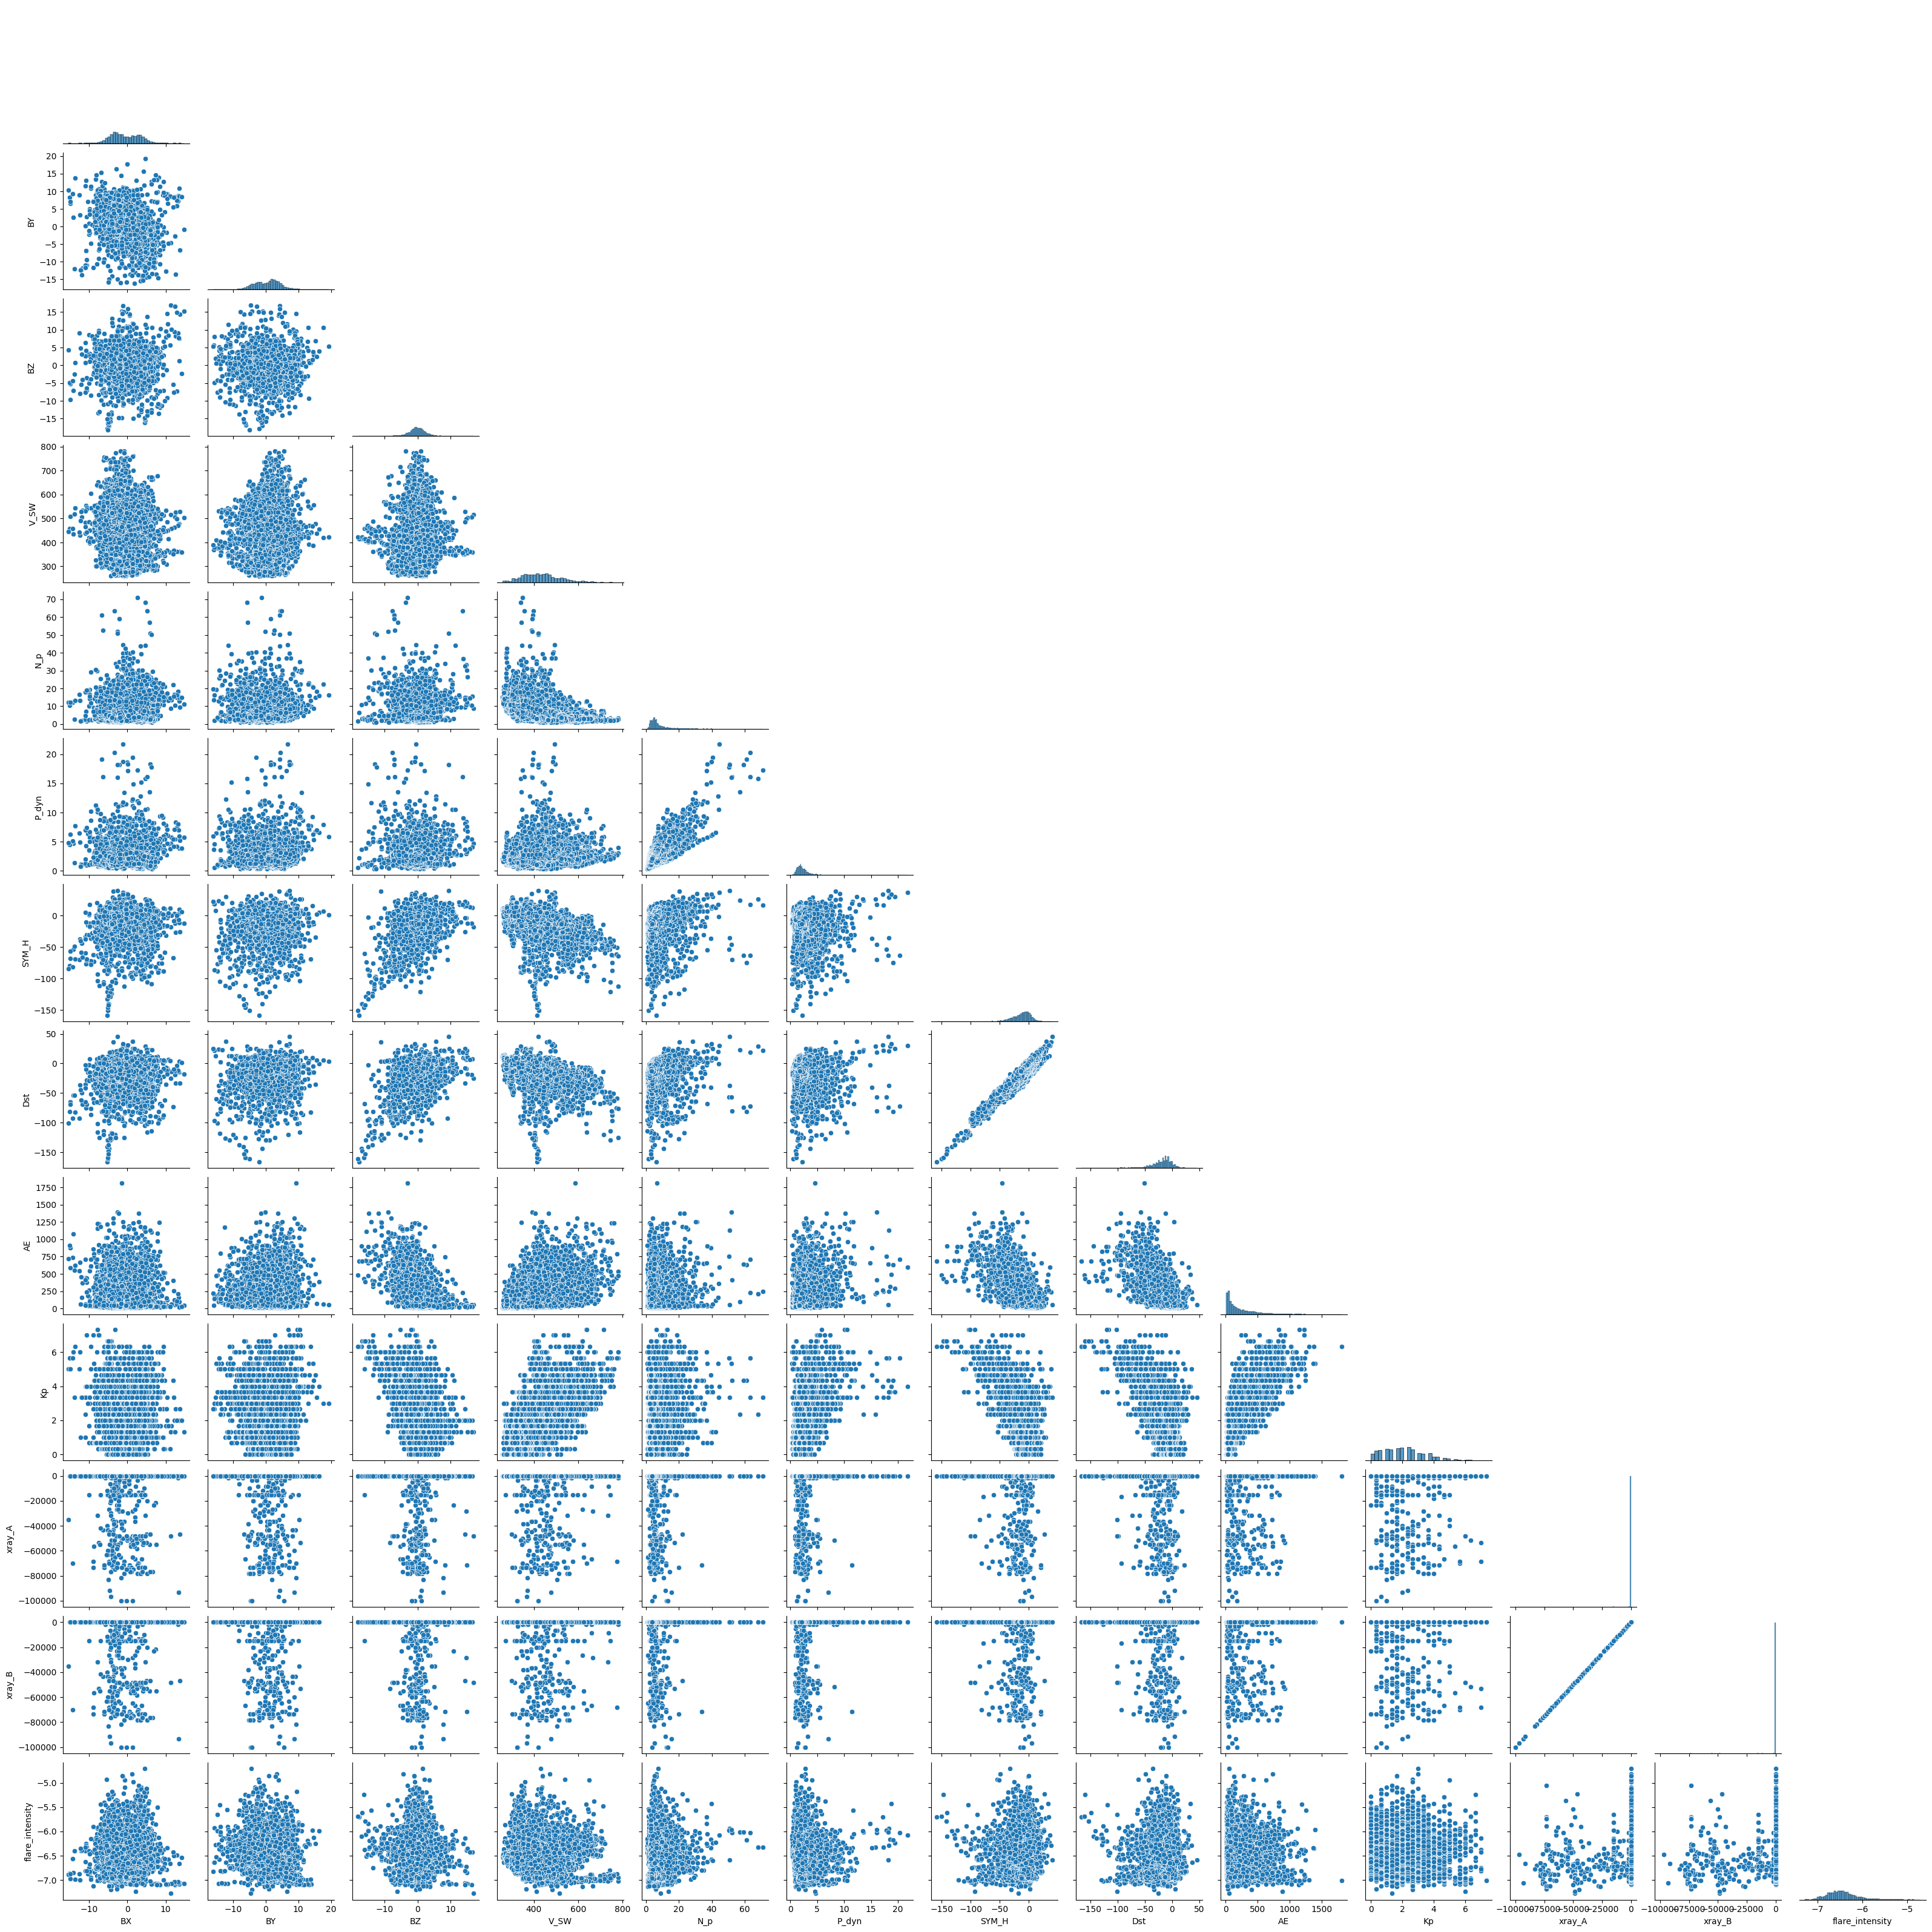

In [ ]:
sns.pairplot(data, corner=True) # check corelative patterns for data transofmration (e.g. log, sqrt, etc.) 
#TODO: check for outliers
#TODO: check for seasonality
#TODO: check for stationarity
#TODO: check for heteroscedasticity
#TODO: check for multicollinearity
#TODO: check for normality


In [ ]:
# Split before interpolation - no data leakage for time series
n = len(data)
train = data.iloc[: int(0.6*n)].copy()
val = data.iloc[int(0.6*n) : int(0.8*n)].copy()
test = data.iloc[int(0.8*n) :].copy()


In [ ]:
train = train.fillna(method='ffill') # fill missing values with forward fill TODO: check if this is the best approach
val = val.fillna(method='ffill')
test = test.fillna(method='ffill')

In [ ]:
data_interpolated = data.interpolate(method='pchip') # interpolate missing values using pchip method
data_interpolated.isna().sum() # check for missing values after interpolation

BX                 0
BY                 0
BZ                 0
V_SW               0
N_p                0
P_dyn              0
SYM_H              0
Dst                0
AE                 0
Kp                 0
xray_A             0
xray_B             0
flare_intensity    0
dtype: int64

In [10]:
data.describe()

,BX,BY,BZ,V_SW,N_p,P_dyn,SYM_H,Dst,AE,Kp,xray_A,xray_B,flare_intensity
count,4977.000000,4977.000000,4977.000000,4975.000000,4975.000000,4975.000000,5065.000000,5064.000000,5064.000000,5065.000000,5.041000e+03,5.041000e+03,5038.000000
mean,-0.522667,0.447445,-0.053320,437.537217,7.428216,2.589338,-13.885969,-18.998025,207.618506,2.124844,-2.026363e+03,-2.026363e+03,-6.447443
std,3.774088,4.246986,3.206480,89.982528,5.899483,1.811516,19.944841,20.085960,216.948505,1.403925,1.061136e+04,1.061136e+04,0.329099
min,-15.421334,-16.148335,-18.132334,259.379430,0.844390,0.339455,-158.400000,-166.000000,7.700000,0.000000,-9.999900e+04,-9.999900e+04,-7.276177
25%,-3.388833,-2.473390,-1.541296,370.529700,4.056820,1.594240,-22.650000,-27.000000,49.729167,1.000000,1.000000e-09,1.995047e-07,-6.673057
50%,-0.920500,0.915000,0.006271,428.054000,5.718936,2.130513,-10.150000,-15.000000,122.958333,2.000000,1.026902e-09,3.265947e-07,-6.477188
75%,2.502203,3.348246,1.591136,488.819610,8.616713,2.938651,-1.133333,-6.000000,293.675000,3.000000,4.597028e-09,5.324960e-07,-6.274657
max,14.757833,19.270338,16.950508,779.994200,70.910000,21.744333,40.050000,45.000000,1810.883333,7.333333,3.237192e-06,1.994482e-05,-4.707588


In [11]:
data_interpolated.describe()

,BX,BY,BZ,V_SW,N_p,P_dyn,SYM_H,Dst,AE,Kp,xray_A,xray_B,flare_intensity
count,5065.000000,5065.000000,5065.000000,5065.000000,5065.000000,5065.000000,5065.000000,5065.000000,5065.000000,5065.000000,5.065000e+03,5.065000e+03,5065.000000
mean,-0.500294,0.435956,-0.032981,437.033777,7.420193,2.582445,-13.885969,-18.996775,207.604092,2.124844,-2.016762e+03,-2.016762e+03,-6.449002
std,3.782218,4.226789,3.196761,89.606846,5.963558,1.824756,19.944841,20.084173,216.929509,1.403925,1.058710e+04,1.058710e+04,0.328946
min,-15.421334,-16.148335,-18.132334,259.379430,0.844390,0.339455,-158.400000,-166.000000,7.700000,0.000000,-9.999900e+04,-9.999900e+04,-7.276177
25%,-3.393793,-2.460833,-1.532667,370.656680,4.032931,1.579167,-22.650000,-27.000000,49.733333,1.000000,1.000000e-09,1.983800e-07,-6.676869
50%,-0.900500,0.892667,0.024000,427.070370,5.694035,2.122400,-10.150000,-15.000000,122.966667,2.000000,1.025634e-09,3.255314e-07,-6.478734
75%,2.578644,3.323221,1.609831,487.925020,8.570218,2.924054,-1.133333,-6.000000,293.666667,3.000000,4.553856e-09,5.308014e-07,-6.275653
max,14.757833,19.270338,16.950508,779.994200,70.910000,21.744333,40.050000,45.000000,1810.883333,7.333333,3.237192e-06,1.994482e-05,-4.707588


<Axes: >

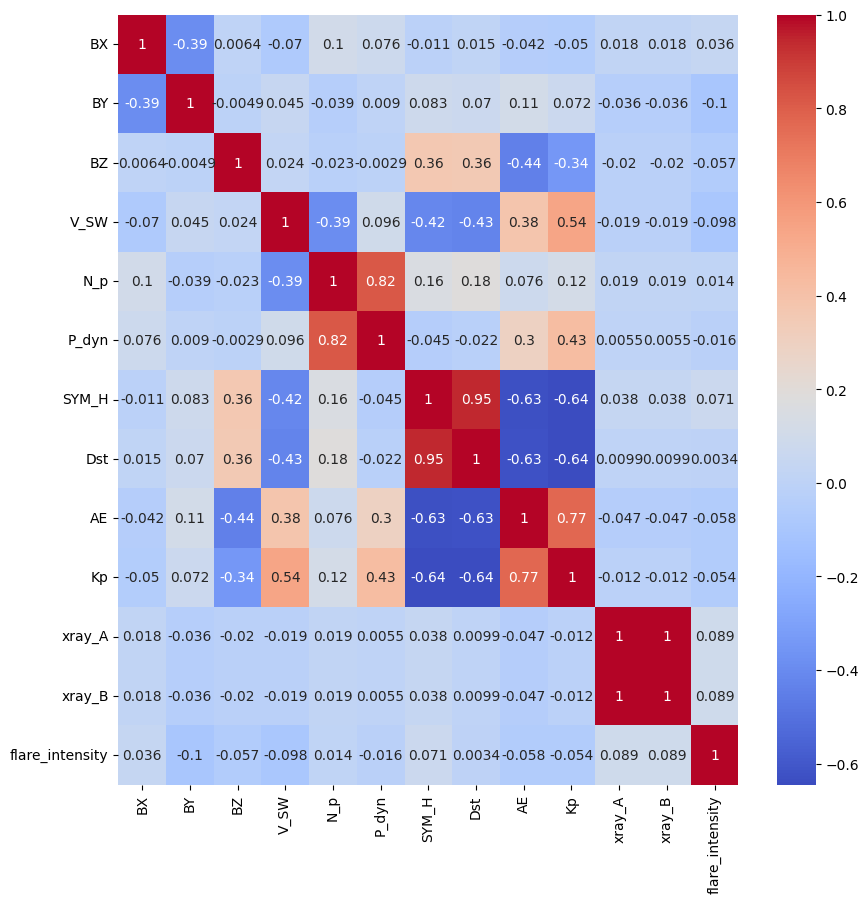

In [12]:
correlation = data_interpolated.corr()
plt.figure(figsize=(10, 10))
sns.heatmap(correlation, annot=True, cmap='coolwarm')

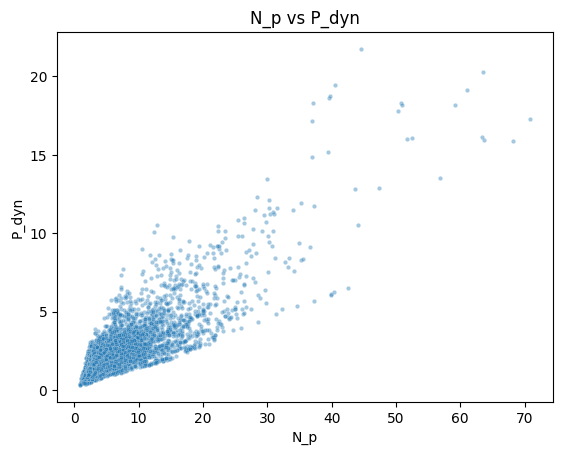

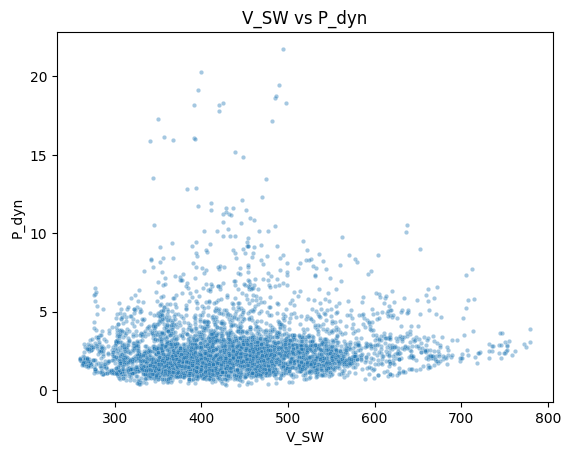

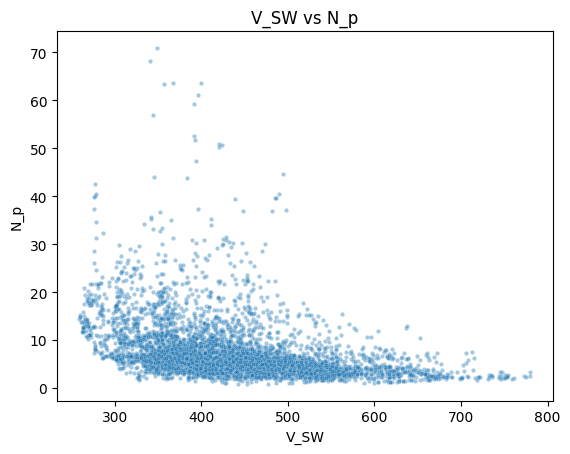

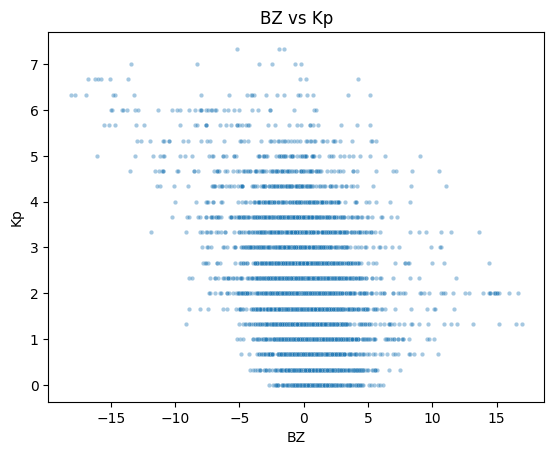

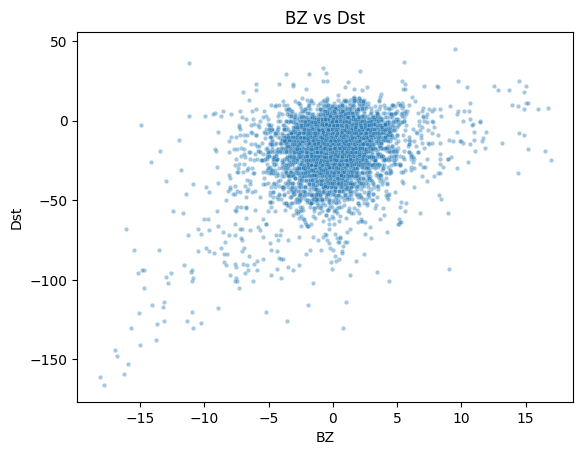

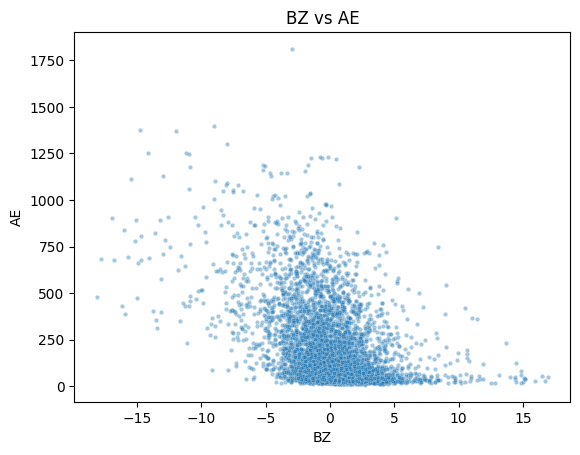

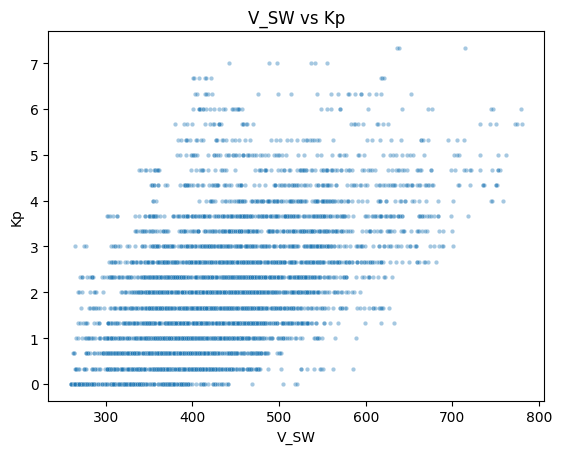

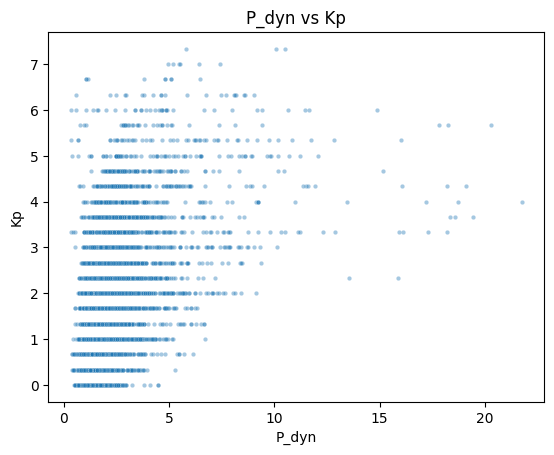

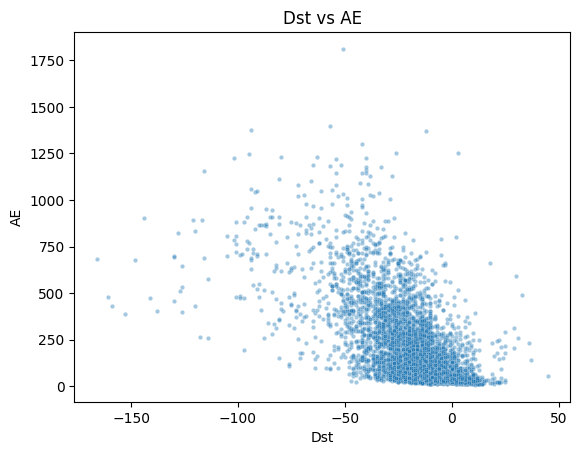

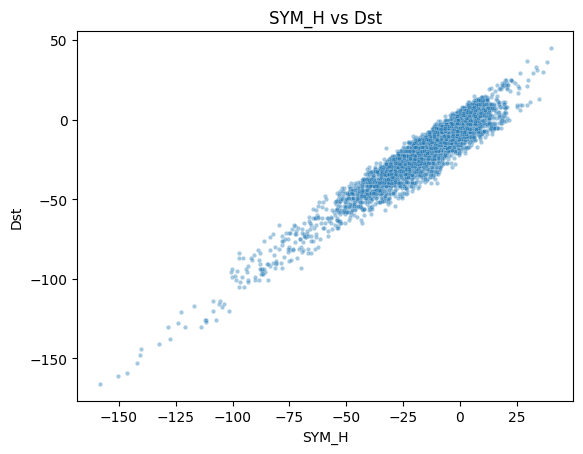

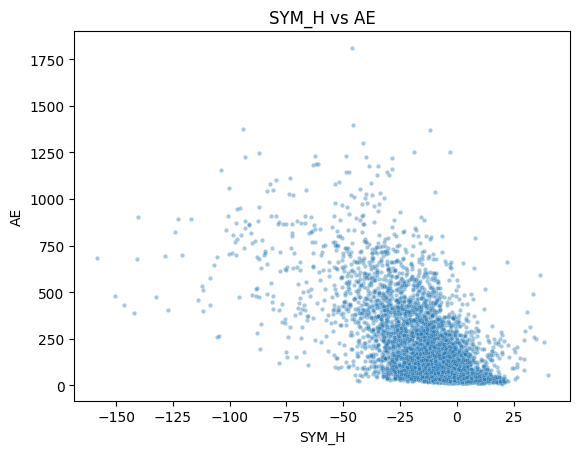

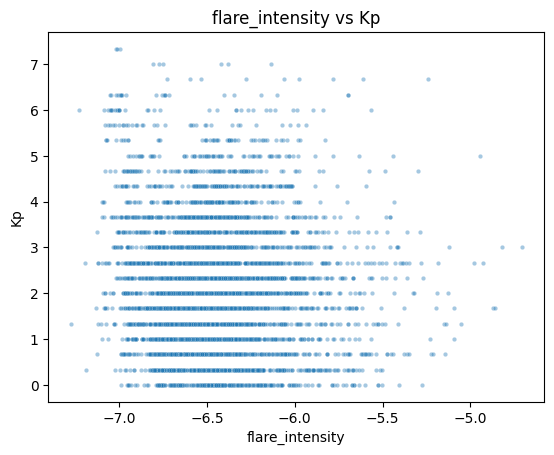

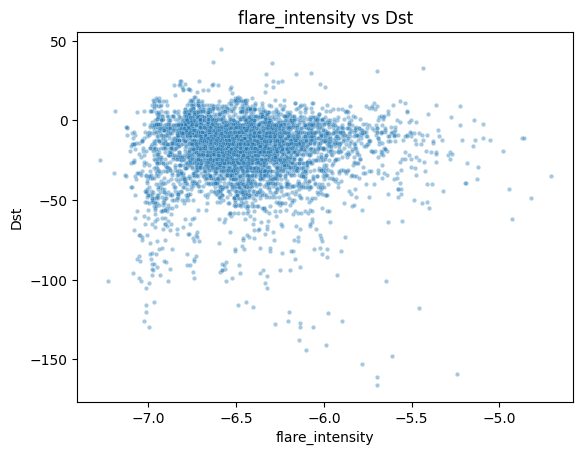

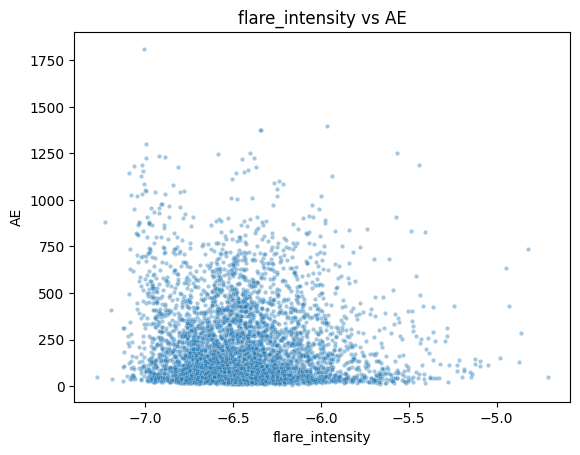

In [13]:
import seaborn as sns
import matplotlib.pyplot as plt

pairs = [
    ("N_p", "P_dyn"),
    ("V_SW", "P_dyn"),
    ("V_SW", "N_p"),
    ("BZ", "Kp"),
    ("BZ", "Dst"),
    ("BZ", "AE"),
    ("V_SW", "Kp"),
    ("P_dyn", "Kp"),
    ("Dst", "AE"),
    ("SYM_H", "Dst"),
    ("SYM_H", "AE"),
    ("flare_intensity", "Kp"),
    ("flare_intensity", "Dst"),
    ("flare_intensity", "AE"),
]

for x, y in pairs:
    sns.scatterplot(data=data_interpolated, x=x, y=y, s=10, alpha=0.4)
    plt.title(f"{x} vs {y}")
    plt.show()


In [14]:
for df in [train, val, test]:
    df["Bz_neg"] = df["BZ"].clip(upper=0)
    df["Bz_int_6h"] = df["Bz_neg"].rolling(window=6, min_periods=1).sum()
    df["VBz"] = df["V_SW"] * df["Bz_neg"].abs()
    df["VBz_int_6h"] = df["VBz"].rolling(window=6, min_periods=1).sum()
    df["dP_dyn"] = df["P_dyn"].diff()
    df["dV_SW"] = df["V_SW"].diff()
    
    for lag in [1, 3, 6]:
        df[f"BZ_lag{lag}"] = df["BZ"].shift(lag)
        df[f"V_SW_lag{lag}"] = df["V_SW"].shift(lag)
        df[f"P_dyn_lag{lag}"] = df["P_dyn"].shift(lag)


In [15]:
for df in [train, val, test]:
    kp_max = df["Kp"].rolling(window=12, min_periods=12).max().shift(-11)
    df["storm_next_12h"] = (kp_max >= 5).astype(float)
    df.dropna(inplace=True)


In [ ]:
X_cols = [
    col for col in train.columns  # Use train.columns, not data.columns!
    if col not in ["Kp", "storm_next_12h", 'AE', 'Dst', 'SYM_H']
]

X_train = train[X_cols]
y_train = train["storm_next_12h"]
X_val = val[X_cols]
y_val = val["storm_next_12h"]
X_test = test[X_cols]
y_test = test["storm_next_12h"]

print(X_train.shape, y_train.shape)
print(X_val.shape, y_val.shape)
print(X_test.shape, y_test.shape)

(3033, 27) (3033,)
(1007, 27) (1007,)
(1007, 27) (1007,)


In [17]:
# Check how imbalanced the data is
print("Class distribution in training set:")
print(y_train.value_counts())
print(f"\nStorm rate: {y_train.mean():.2%}")


Class distribution in training set:
storm_next_12h
0.0    2651
1.0     382
Name: count, dtype: int64

Storm rate: 12.59%


In [18]:
# XGBoost with class weights to handle imbalance
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

xgb_model= XGBClassifier(
    max_depth=6,
    learning_rate=0.05,
    n_estimators=2000,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=3,
    gamma=0,
    reg_lambda=1,
    reg_alpha=0,
)
print("Training XGBoost...")
xgb_model.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    verbose=True
)

xgb_model.fit(X_train, y_train)
print("✓ Training complete!")

# Predictions
y_pred_train = xgb_model.predict(X_train)
y_pred_val = xgb_model.predict(X_val)
y_pred_test = xgb_model.predict(X_test)

y_pred_proba_val = xgb_model.predict_proba(X_val)[:, 1]
y_pred_proba_test = xgb_model.predict_proba(X_test)[:, 1]


Training XGBoost...
[0]	validation_0-logloss:0.20184
[1]	validation_0-logloss:0.19697
[2]	validation_0-logloss:0.19121
[3]	validation_0-logloss:0.18605
[4]	validation_0-logloss:0.18172
[5]	validation_0-logloss:0.17740
[6]	validation_0-logloss:0.17484
[7]	validation_0-logloss:0.17211
[8]	validation_0-logloss:0.16978
[9]	validation_0-logloss:0.16763
[10]	validation_0-logloss:0.16517
[11]	validation_0-logloss:0.16329
[12]	validation_0-logloss:0.16153
[13]	validation_0-logloss:0.15972
[14]	validation_0-logloss:0.15760
[15]	validation_0-logloss:0.15667
[16]	validation_0-logloss:0.15500
[17]	validation_0-logloss:0.15407
[18]	validation_0-logloss:0.15257
[19]	validation_0-logloss:0.15068
[20]	validation_0-logloss:0.14973
[21]	validation_0-logloss:0.14837
[22]	validation_0-logloss:0.14724
[23]	validation_0-logloss:0.14611
[24]	validation_0-logloss:0.14481
[25]	validation_0-logloss:0.14373
[26]	validation_0-logloss:0.14356
[27]	validation_0-logloss:0.14258
[28]	validation_0-logloss:0.14168
[29]

In [19]:
print("=" * 60)
print("VALIDATION SET PERFORMANCE")
print("=" * 60)
print(classification_report(y_val, y_pred_val, target_names=['No Storm', 'Storm']))
print(f"ROC-AUC Score: {roc_auc_score(y_val, y_pred_proba_val):.4f}")

print("\n" + "=" * 60)
print("TEST SET PERFORMANCE")
print("=" * 60)
print(classification_report(y_test, y_pred_test, target_names=['No Storm', 'Storm']))
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_pred_proba_test):.4f}")

# Confusion Matrix
print("\nConfusion Matrix (Test Set):")
cm = confusion_matrix(y_test, y_pred_test)
print(cm)
print(f"\nTrue Negatives: {cm[0,0]}, False Positives: {cm[0,1]}")
print(f"False Negatives: {cm[1,0]}, True Positives: {cm[1,1]}")


VALIDATION SET PERFORMANCE
              precision    recall  f1-score   support

    No Storm       0.98      0.96      0.97       968
       Storm       0.32      0.41      0.36        39

    accuracy                           0.94      1007
   macro avg       0.65      0.69      0.66      1007
weighted avg       0.95      0.94      0.95      1007

ROC-AUC Score: 0.9235

TEST SET PERFORMANCE
              precision    recall  f1-score   support

    No Storm       0.93      0.99      0.96       918
       Storm       0.59      0.18      0.28        89

    accuracy                           0.92      1007
   macro avg       0.76      0.58      0.62      1007
weighted avg       0.90      0.92      0.90      1007

ROC-AUC Score: 0.7763

Confusion Matrix (Test Set):
[[907  11]
 [ 73  16]]

True Negatives: 907, False Positives: 11
False Negatives: 73, True Positives: 16



Top 15 Most Important Features:
            feature  importance
8                AE    0.157969
5             P_dyn    0.130919
20       P_dyn_lag1    0.077689
7               Dst    0.066404
12           Bz_neg    0.044204
11  flare_intensity    0.043364
6             SYM_H    0.034228
3              V_SW    0.031184
25        V_SW_lag6    0.030173
26       P_dyn_lag6    0.028221
0                BX    0.027881
22        V_SW_lag3    0.027180
1                BY    0.025230
23       P_dyn_lag3    0.023842
10           xray_B    0.023645


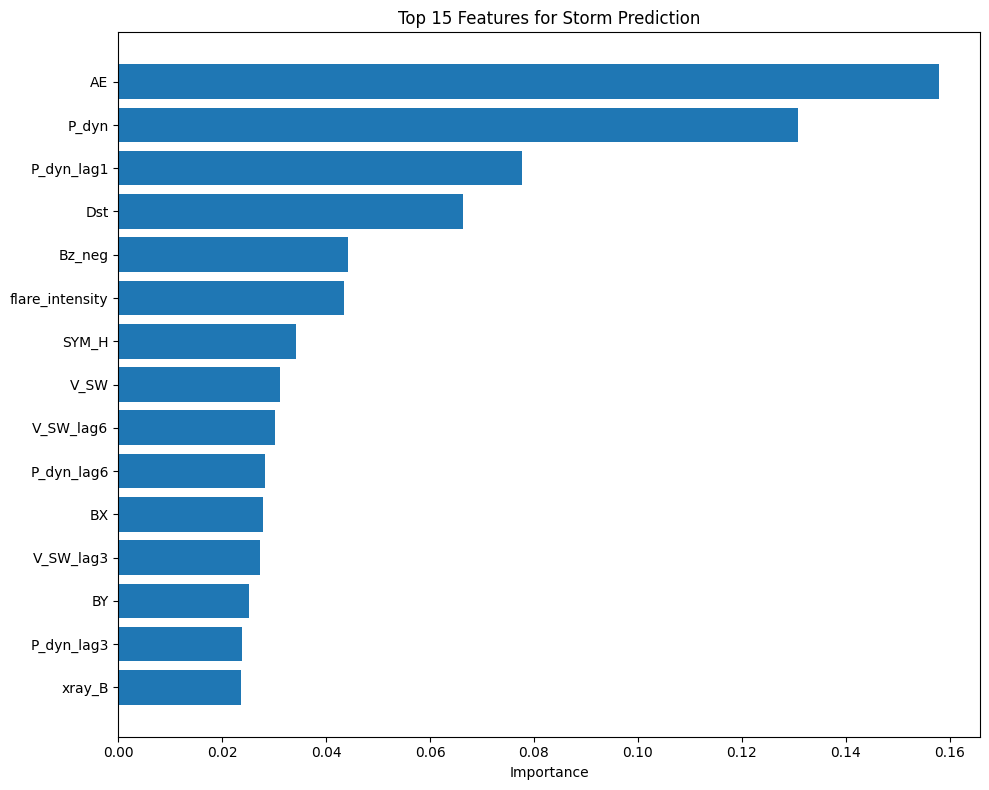

In [20]:
# See which space weather variables matter most
feature_importance = pd.DataFrame({
    'feature': X_train.columns,
    'importance': xgb_model.feature_importances_
}).sort_values('importance', ascending=False)

print("\nTop 15 Most Important Features:")
print(feature_importance.head(15))

# Plot
plt.figure(figsize=(10, 8))
plt.barh(feature_importance.head(15)['feature'], feature_importance.head(15)['importance'])
plt.xlabel('Importance')
plt.title('Top 15 Features for Storm Prediction')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


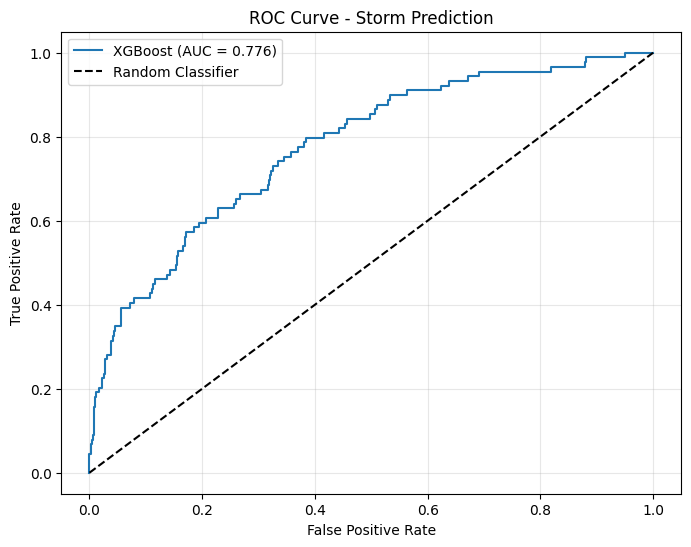

In [21]:
# Plot ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba_test)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'XGBoost (AUC = {roc_auc_score(y_test, y_pred_proba_test):.3f})')
plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Storm Prediction')
plt.legend()
plt.grid(alpha=0.3)
plt.show()
